# Retail Demand & Inventory Analytics
**Jaden Boothe**

## Step 1: Load the data

In [2]:
import pandas as pd

raw = pd.read_csv("../data/retail_weekly_raw.csv", parse_dates=["week_start"])

print(raw.shape)
raw.head()

(29992, 16)


,week_start,product_id,product_name,category,brand,region,regular_price,selling_price,discount_pct,promo_flag,units_sold,revenue,inventory_received,inventory_on_hand,inventory_on_order,stockout_flag
0,2026-08-24,P1020,StudioRef Wired,Headphones,Sonar,West,199,199.00,0.0,0,4,796.00,0,284.0,0,0
1,2025-08-18,P1041,FrostFree French-Door Fridge,Appliances,Kelvin,Northeast,2299,2299.00,0.0,0,6,13794.00,5,10.0,21,0
2,2024-01-29,P1039,Handheld PC Deck,Gaming,Novatek,West,549,532.53,3.0,0,10,5325.30,3,25.0,18,0
3,2023-10-30,P1046,Espresso Barista Pro,Appliances,HomeLab,West,699,678.03,3.0,0,7,4746.21,9,21.0,44,0
4,2026-09-07,P1045,RoboVac S8,Appliances,HomeLab,West,399,379.05,5.0,0,32,12129.60,0,59.0,87,0


In [3]:
print(raw.duplicated().sum())

40


In [4]:
df = raw.drop_duplicates().copy()

print(df.shape)
print(df.duplicated(subset=["product_id", "region", "week_start"]).sum())

(29952, 16)
0


In [5]:
print(df.isna().sum())

week_start             0
product_id             0
product_name           0
category               0
brand                 30
region                 0
regular_price          0
selling_price          0
discount_pct           0
promo_flag             0
units_sold             0
revenue                0
inventory_received     0
inventory_on_hand     30
inventory_on_order     0
stockout_flag          0
dtype: int64


In [6]:
brand_lookup = df.dropna(subset=["brand"]).groupby("product_id")["brand"].first()
df["brand"] = df["brand"].fillna(df["product_id"].map(brand_lookup))

print(df["brand"].isna().sum())

0


In [7]:
df.groupby("product_id")["brand"].nunique().max()

np.int64(1)

In [8]:
df = df.sort_values(["product_id", "region", "week_start"]).reset_index(drop=True)

last_week_inv = df.groupby(["product_id", "region"])["inventory_on_hand"].shift(1)
calculated = last_week_inv + df["inventory_received"] - df["units_sold"]

df["inventory_on_hand"] = df["inventory_on_hand"].fillna(calculated)
print(df["inventory_on_hand"].isna().sum())

0


In [9]:
neg = df[df["units_sold"] < 0]

print(len(neg))
neg[["product_name", "units_sold", "selling_price", "revenue"]].head()

15


,product_name,units_sold,selling_price,revenue
1391,GameForce 16 RTX,-9,1745.03,15705.27
1562,GameForce 16 RTX,-7,1799.00,12593.00
2624,CreatorPro 16,-7,2133.03,14931.21
3482,Chromebook Go 11,-53,279.00,14787.00
9665,"Vivid 77"" OLED",-6,2715.03,16290.18


In [10]:
df.loc[df["units_sold"] < 0, "units_sold"] = df["units_sold"].abs()

print((df["units_sold"] < 0).sum())

0


In [11]:
bad = df[df["selling_price"] > df["regular_price"]]

print(len(bad))
bad[["product_name", "regular_price", "selling_price", "discount_pct", "revenue", "units_sold"]]

8


,product_name,regular_price,selling_price,discount_pct,revenue,units_sold
1536,GameForce 16 RTX,1799,17990.0,0.0,10794.00,6
4077,FlexFold 14 2-in-1,1099,10440.5,5.0,15660.75,15
4944,WorkStation X1,1499,14990.0,0.0,10493.00,7
14732,SleepBuds,229,2290.0,0.0,3206.00,14
15926,Nova 16,799,7750.3,3.0,72077.79,93
26340,QuickDry Electric Dryer,999,9690.3,3.0,7752.24,8
26742,QuickDry Electric Dryer,999,9690.3,3.0,4845.15,5
27991,RoboVac S8,399,3990.0,0.0,5985.00,15


In [12]:
bad_rows = df["selling_price"] > df["regular_price"]
df.loc[bad_rows, "selling_price"] = (df.loc[bad_rows, "regular_price"] * (1 - df.loc[bad_rows, "discount_pct"] / 100)).round(2)

print((df["selling_price"] > df["regular_price"]).sum())

0


In [13]:
((df["units_sold"] * df["selling_price"] - df["revenue"]).abs() < 0.05).mean()

np.float64(1.0)

In [14]:
df["category"].value_counts()

category
Headphones     4990
Laptops        4989
TVs            4989
Smartphones    4987
Gaming         4987
Appliances     4985
tvs              25
Name: count, dtype: int64

In [15]:
df.to_csv("../data/retail_weekly_clean.csv", index=False)

In [16]:
print("Rows:", raw.shape[0], "| Duplicates:", raw.duplicated().sum())
print("\nMissing values:\n", raw.isna().sum()[raw.isna().sum() > 0])
print("\nNumber ranges:\n", raw.describe().T[["min", "max"]])
print("\nCategory labels:\n", raw["category"].value_counts())

Rows: 29992 | Duplicates: 40

Missing values:
 brand                30
inventory_on_hand    30
dtype: int64

Number ranges:
                                     min                  max
week_start          2023-10-02 00:00:00  2026-09-21 00:00:00
regular_price                      79.0               2999.0
selling_price                     55.09              17990.0
discount_pct                        0.0                 32.0
promo_flag                          0.0                  1.0
units_sold                       -253.0               1457.0
revenue                             0.0            231587.44
inventory_received                  0.0               1497.0
inventory_on_hand                   0.0               1296.0
inventory_on_order                  0.0               1631.0
stockout_flag                       0.0                  1.0

Category labels:
 category
Headphones     4998
Smartphones    4998
TVs            4995
Gaming         4994
Laptops        4994
Appliances     

In [17]:
total_revenue = df["revenue"].sum()
total_units = df["units_sold"].sum()
asp = total_revenue / total_units

print(f"Total revenue: ${total_revenue:,.0f}")
print(f"Units sold: {total_units:,.0f}")
print(f"Average selling price: ${asp:,.2f}")

Total revenue: $519,389,066
Units sold: 1,005,572
Average selling price: $516.51


In [18]:
last_week = df["week_start"].max()

last_52 = df[df["week_start"] > last_week - pd.Timedelta(weeks=52)]
prior_52 = df[(df["week_start"] <= last_week - pd.Timedelta(weeks=52)) &
              (df["week_start"] > last_week - pd.Timedelta(weeks=104))]

rev_now, rev_before = last_52["revenue"].sum(), prior_52["revenue"].sum()
growth = rev_now / rev_before - 1

print(f"Last 52 weeks:  ${rev_now:,.0f}")
print(f"Prior 52 weeks: ${rev_before:,.0f}")
print(f"Revenue growth: {growth:+.1%}")

Last 52 weeks:  $184,103,768
Prior 52 weeks: $172,003,228
Revenue growth: +7.0%


In [19]:
units_now = last_52["units_sold"].sum()
units_before = prior_52["units_sold"].sum()
units_growth = units_now / units_before - 1

print(f"Units growth: {units_growth:+.1%}")

Units growth: +3.5%


In [20]:
cat_now = last_52.groupby("category")[["revenue", "units_sold"]].sum()
cat_before = prior_52.groupby("category")[["revenue", "units_sold"]].sum()

cat = cat_now.copy()
cat["revenue_share"] = cat["revenue"] / cat["revenue"].sum()
cat["revenue_growth"] = cat_now["revenue"] / cat_before["revenue"] - 1
cat["units_growth"] = cat_now["units_sold"] / cat_before["units_sold"] - 1

cat.sort_values("revenue", ascending=False).round(3)

,revenue,units_sold,revenue_share,revenue_growth,units_growth
category,,,,,
Smartphones,52323615.63,71315,0.284,0.076,0.054
Laptops,42540034.84,46518,0.231,0.051,-0.022
TVs,40335638.75,39486,0.219,0.078,-0.104
Headphones,18431387.70,115394,0.100,0.104,0.102
Gaming,17391228.78,42290,0.094,0.090,0.064
Appliances,13029413.59,30231,0.071,0.028,0.021
tvs,52448.53,155,0.000,-0.723,-0.408


In [21]:
tv_now = last_52[last_52["category"] == "TVs"].groupby("product_name")[["revenue", "units_sold"]].sum()
tv_before = prior_52[prior_52["category"] == "TVs"].groupby("product_name")[["revenue", "units_sold"]].sum()

tv = tv_now.copy()
tv["units_growth"] = tv_now["units_sold"] / tv_before["units_sold"] - 1
tv["avg_price"] = tv_now["revenue"] / tv_now["units_sold"]

tv.sort_values("units_growth", ascending=False).round(2)

,revenue,units_sold,units_growth,avg_price
product_name,,,,
"Cinema 85"" Mini-LED",6112866.70,2144,0.32,2851.15
"Crystal 75"" QLED",6566610.87,4652,0.26,1411.57
"Vivid 65"" OLED",8842364.18,4686,0.14,1886.97
"Vivid 77"" OLED",5085361.93,1946,0.11,2613.24
"Vivid 55"" OLED",7218196.48,5444,0.02,1325.90
"Crystal 50"" 4K",3675239.74,8722,-0.08,421.38
"Budget 43"" 4K",2418937.69,9189,-0.19,263.24
"Smart 32"" HD",416061.16,2703,-0.60,153.93


In [22]:
recent = df[df["week_start"] > last_week - pd.Timedelta(weeks=8)]
avg_weekly = recent.groupby("product_name")["units_sold"].sum() / 8

on_hand = df[df["week_start"] == last_week].groupby("product_name")["inventory_on_hand"].sum()

wos = pd.DataFrame({"on_hand": on_hand, "avg_weekly_sales": avg_weekly})
wos["weeks_of_supply"] = wos["on_hand"] / wos["avg_weekly_sales"]

wos.sort_values("weeks_of_supply", ascending=False).round(1)

,on_hand,avg_weekly_sales,weeks_of_supply
product_name,,,
"Smart 32"" HD",1653.0,30.6,54.0
VR Vision Headset,217.0,5.5,39.5
Gaming Chair Apex,722.0,19.1,37.8
StudioRef Wired,627.0,25.1,25.0
Chromebook Go 11,409.0,54.5,7.5
BassBoom On-Ear,315.0,64.6,4.9
Nova 16 Pro,939.0,254.9,3.7
Racing Wheel Pro,44.0,13.2,3.3
CreatorPro 16,113.0,34.2,3.3


In [23]:
on_order = df[df["week_start"] == last_week].groupby("product_name")["inventory_on_order"].sum()

wos["on_order"] = on_order
wos["weeks_of_cover"] = (wos["on_hand"] + wos["on_order"]) / wos["avg_weekly_sales"]

wos.sort_values("weeks_of_cover").head(8).round(1)

,on_hand,avg_weekly_sales,weeks_of_supply,on_order,weeks_of_cover
product_name,,,,,
SwiftAir 13,490.0,328.5,1.5,359,2.6
"Cinema 85"" Mini-LED",67.0,39.9,1.7,40,2.7
FlexFold 14 2-in-1,240.0,127.2,1.9,130,2.9
StudyMate 15,577.0,230.1,2.5,102,3.0
SleepBuds,189.0,130.5,1.4,197,3.0
GameForce 16 RTX,161.0,69.1,2.3,47,3.0
AirBuds Lite,850.0,714.8,1.2,1353,3.1
"Crystal 75"" QLED",44.0,79.4,0.6,201,3.1


In [24]:
on_order = df[df["week_start"] == last_week].groupby("product_name")["inventory_on_order"].sum()

wos["on_order"] = on_order
wos["weeks_of_cover"] = (wos["on_hand"] + wos["on_order"]) / wos["avg_weekly_sales"]

wos.sort_values("weeks_of_cover").head(8).round(1)

,on_hand,avg_weekly_sales,weeks_of_supply,on_order,weeks_of_cover
product_name,,,,,
SwiftAir 13,490.0,328.5,1.5,359,2.6
"Cinema 85"" Mini-LED",67.0,39.9,1.7,40,2.7
FlexFold 14 2-in-1,240.0,127.2,1.9,130,2.9
StudyMate 15,577.0,230.1,2.5,102,3.0
SleepBuds,189.0,130.5,1.4,197,3.0
GameForce 16 RTX,161.0,69.1,2.3,47,3.0
AirBuds Lite,850.0,714.8,1.2,1353,3.1
"Crystal 75"" QLED",44.0,79.4,0.6,201,3.1


In [25]:
df["month"] = df["week_start"].dt.month

monthly = df.groupby(["category", "month"])["units_sold"].sum().unstack("category")
index = monthly / monthly.mean()

index.round(2)

category,Appliances,Gaming,Headphones,Laptops,Smartphones,TVs,tvs
month,,,,,,,
1,0.76,0.68,0.68,0.70,0.73,0.88,0.72
2,0.76,0.68,0.68,0.66,0.71,0.77,0.64
3,1.00,0.91,0.94,0.90,0.99,0.86,2.20
4,0.98,0.87,0.84,0.86,0.92,0.82,1.22
5,1.02,0.78,0.90,0.74,0.85,0.74,0.85
6,1.04,0.99,0.95,0.89,0.99,0.87,1.01
7,1.15,0.91,0.90,1.16,0.90,0.78,0.21
8,0.98,0.89,0.91,1.36,0.92,0.80,1.30
9,0.98,0.90,0.89,0.83,1.38,0.82,NaN


In [26]:
weekly_rev = df.groupby("week_start")["revenue"].sum()
bf_weeks = weekly_rev.groupby(weekly_rev.index.year).idxmax()

print("Black Friday weeks:", list(bf_weeks.dt.date))
print(f"Stockout rate, all weeks: {df['stockout_flag'].mean():.1%}")
print(f"Stockout rate, Black Friday weeks: {df[df['week_start'].isin(bf_weeks)]['stockout_flag'].mean():.1%}")

Black Friday weeks: [datetime.date(2023, 11, 20), datetime.date(2024, 11, 25), datetime.date(2025, 11, 24), datetime.date(2026, 9, 21)]
Stockout rate, all weeks: 3.0%
Stockout rate, Black Friday weeks: 10.7%


In [27]:
promo = df.groupby(["category", "promo_flag"])["units_sold"].mean().unstack()
promo.columns = ["no_promo", "promo"]
promo["lift"] = promo["promo"] / promo["no_promo"] - 1

promo.sort_values("lift", ascending=False).round(2)

,no_promo,promo,lift
category,,,
Gaming,21.58,42.35,0.96
TVs,23.60,45.88,0.94
Headphones,56.32,109.16,0.94
Laptops,25.93,47.65,0.84
Smartphones,39.53,62.40,0.58
Appliances,16.65,23.62,0.42
tvs,28.91,28.00,-0.03


In [28]:
df["category"] = df["category"].replace({"tvs": "TVs"})
print(df["category"].nunique())   # should print 6

6


In [29]:
normal = df[~df["week_start"].dt.month.isin([11, 12])]

fair = normal.groupby(["category", "promo_flag"])["units_sold"].mean().unstack()
fair.columns = ["no_promo", "promo"]
fair["fair_lift"] = fair["promo"] / fair["no_promo"] - 1

fair["raw_lift"] = promo["lift"]
fair.sort_values("fair_lift", ascending=False).round(2)

,no_promo,promo,fair_lift,raw_lift
category,,,,
Laptops,23.96,38.85,0.62,0.84
Smartphones,37.43,52.82,0.41,0.58
TVs,20.82,28.10,0.35,0.94
Headphones,52.27,70.00,0.34,0.94
Appliances,16.16,21.23,0.31,0.42
Gaming,19.92,25.88,0.30,0.96


In [30]:
weekly = df.groupby(["category", "week_start"])["units_sold"].sum().unstack("category")

test_weeks = pd.date_range("2025-09-29", periods=13, freq="W-MON")
actual = weekly.loc[test_weeks]
naive_fc = weekly.shift(52).loc[test_weeks]

wape = (actual - naive_fc).abs().sum() / actual.sum()
print(wape.round(3))
print("Overall WAPE:", round((actual - naive_fc).abs().sum().sum() / actual.sum().sum(), 3))

category
Appliances     0.105
Gaming         0.091
Headphones     0.123
Laptops        0.063
Smartphones    0.058
TVs            0.145
dtype: float64
Overall WAPE: 0.101


In [31]:
cutoff = test_weeks[0]
recent = weekly.loc[cutoff - pd.Timedelta(weeks=13) : cutoff - pd.Timedelta(weeks=1)]
recent_last_year = weekly.shift(52).loc[recent.index]

trend = recent.sum() / recent_last_year.sum()
yoy_fc = naive_fc * trend

wape_yoy = (actual - yoy_fc).abs().sum() / actual.sum()

print("Trend factor:\n", trend.round(3))
print("\nWAPE, naive vs trend-adjusted:")
print(pd.DataFrame({"naive": wape, "trend_adjusted": wape_yoy}).round(3))
print("Overall:", round((actual - yoy_fc).abs().sum().sum() / actual.sum().sum(), 3))

Trend factor:
 category
Appliances     1.074
Gaming         0.989
Headphones     1.090
Laptops        0.916
Smartphones    0.907
TVs            0.917
dtype: float64

WAPE, naive vs trend-adjusted:
             naive  trend_adjusted
category                          
Appliances   0.105           0.114
Gaming       0.091           0.096
Headphones   0.123           0.074
Laptops      0.063           0.072
Smartphones  0.058           0.102
TVs          0.145           0.079
Overall: 0.085


In [32]:
future_weeks = pd.date_range(weekly.index.max() + pd.Timedelta(weeks=1), periods=13, freq="W-MON")
last_year_same_weeks = weekly.reindex(future_weeks - pd.Timedelta(weeks=52))
last_year_same_weeks.index = future_weeks

recent = weekly.iloc[-13:]
trend_now = recent.sum() / weekly.shift(52).iloc[-13:].sum()

forecast = last_year_same_weeks * trend_now

summary = pd.DataFrame({
    "Q4 2025 actual": last_year_same_weeks.sum(),
    "Q4 2026 forecast": forecast.sum(),
})
summary["change"] = summary["Q4 2026 forecast"] / summary["Q4 2025 actual"] - 1
summary.round(2)

,Q4 2025 actual,Q4 2026 forecast,change
category,,,
Appliances,8318,8288.83,-0.00
Gaming,15258,16319.17,0.07
Headphones,41648,46358.06,0.11
Laptops,15196,15094.83,-0.01
Smartphones,21792,24143.36,0.11
TVs,15294,13930.85,-0.09


In [33]:
def action(row):
    if row["weeks_of_cover"] < 3:
        return "INCREASE"
    elif row["weeks_of_supply"] > 12:
        return "REDUCE"
    else:
        return "OK"

wos["action"] = wos.apply(action, axis=1)
wos[wos["action"] != "OK"].sort_values("action")

,on_hand,avg_weekly_sales,weeks_of_supply,on_order,weeks_of_cover,action
product_name,,,,,,
"Cinema 85"" Mini-LED",67.0,39.875,1.680251,40,2.683386,INCREASE
FlexFold 14 2-in-1,240.0,127.250,1.886051,130,2.907662,INCREASE
SleepBuds,189.0,130.500,1.448276,197,2.957854,INCREASE
StudyMate 15,577.0,230.125,2.507333,102,2.950570,INCREASE
SwiftAir 13,490.0,328.500,1.491629,359,2.584475,INCREASE
Gaming Chair Apex,722.0,19.125,37.751634,0,37.751634,REDUCE
"Smart 32"" HD",1653.0,30.625,53.975510,0,53.975510,REDUCE
StudioRef Wired,627.0,25.125,24.955224,0,24.955224,REDUCE
VR Vision Headset,217.0,5.500,39.454545,0,39.454545,REDUCE


Matplotlib is building the font cache; this may take a moment.


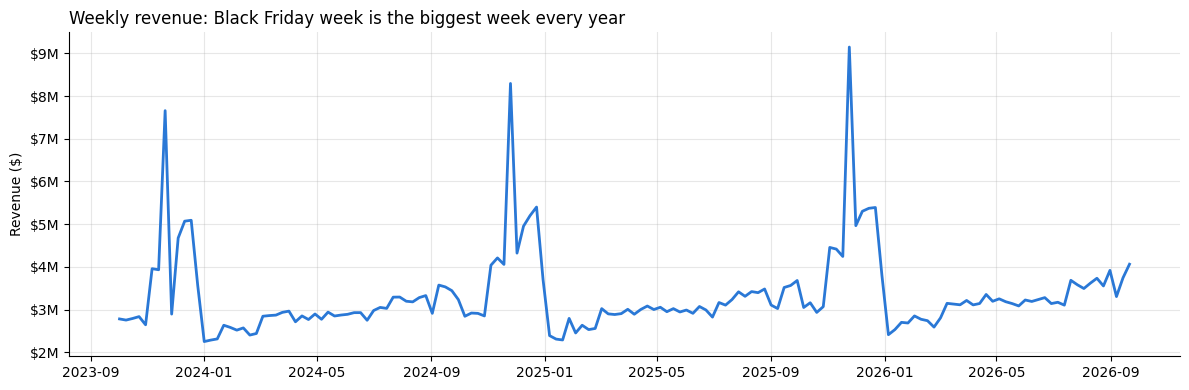

In [34]:
import matplotlib.pyplot as plt

weekly_revenue = df.groupby("week_start")["revenue"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(weekly_revenue.index, weekly_revenue.values, color="#2a78d6", linewidth=2)

ax.set_title("Weekly revenue: Black Friday week is the biggest week every year", loc="left")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(lambda x, _: f"${x/1e6:.0f}M")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../weekly_revenue.png", dpi=150)
plt.show()

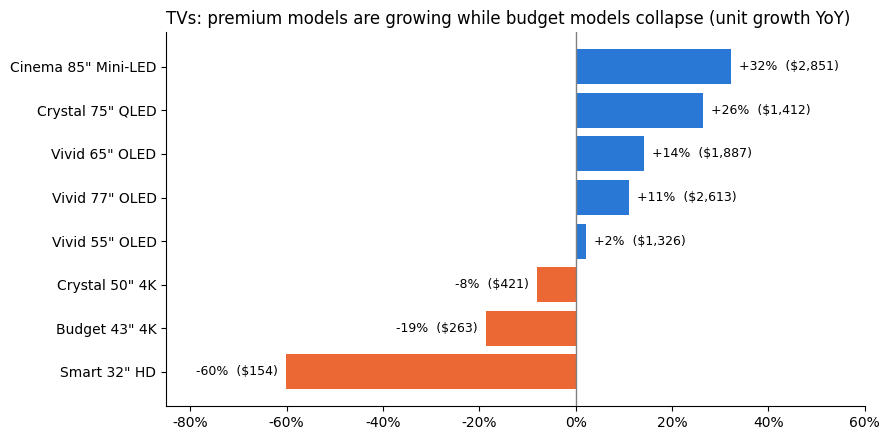

In [35]:
tv_sorted = tv.sort_values("units_growth")
colors = ["#2a78d6" if g > 0 else "#eb6834" for g in tv_sorted["units_growth"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(tv_sorted.index, tv_sorted["units_growth"], color=colors)

for i, (g, price) in enumerate(zip(tv_sorted["units_growth"], tv_sorted["avg_price"])):
    ax.text(g, i, f"  {g:+.0%}  (${price:,.0f})" if g > 0 else f"{g:+.0%}  (${price:,.0f})  ",
            va="center", ha="left" if g > 0 else "right", fontsize=9)

ax.axvline(0, color="gray", linewidth=1)
ax.set_title("TVs: premium models are growing while budget models collapse (unit growth YoY)", loc="left")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_xlim(-0.85, 0.6)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../tv_mix_shift.png", dpi=150)
plt.show()

                       units_sold  revenue
segment                                   
Budget (under $1,000)      -0.254   -0.205
Premium ($1,000+)           0.144    0.152


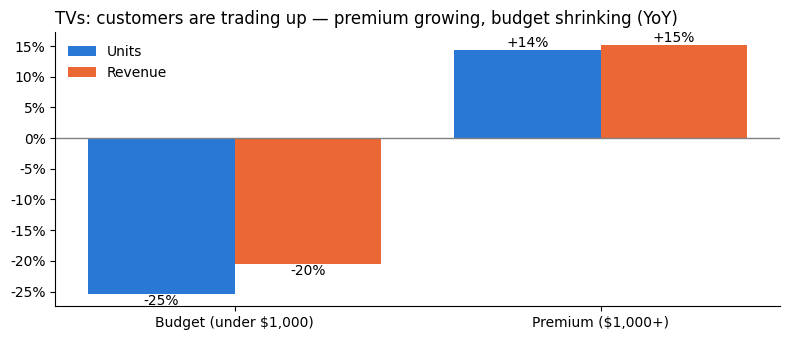

In [36]:
tvs = df[df["category"] == "TVs"].copy()
tvs["segment"] = tvs["regular_price"].apply(lambda p: "Premium ($1,000+)" if p >= 1000 else "Budget (under $1,000)")

seg_now = tvs[tvs["week_start"].isin(last_52["week_start"])].groupby("segment")[["units_sold", "revenue"]].sum()
seg_before = tvs[tvs["week_start"].isin(prior_52["week_start"])].groupby("segment")[["units_sold", "revenue"]].sum()
seg_growth = seg_now / seg_before - 1
print(seg_growth.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
x = range(len(seg_growth))
ax.bar([i - 0.2 for i in x], seg_growth["units_sold"], width=0.4, color="#2a78d6", label="Units")
ax.bar([i + 0.2 for i in x], seg_growth["revenue"], width=0.4, color="#eb6834", label="Revenue")

for i, (u, r) in enumerate(zip(seg_growth["units_sold"], seg_growth["revenue"])):
    ax.text(i - 0.2, u, f"{u:+.0%}", ha="center", va="bottom" if u > 0 else "top")
    ax.text(i + 0.2, r, f"{r:+.0%}", ha="center", va="bottom" if r > 0 else "top")

ax.set_xticks(list(x), seg_growth.index)
ax.axhline(0, color="gray", linewidth=1)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.set_title("TVs: customers are trading up — premium growing, budget shrinking (YoY)", loc="left")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../tv_mix_shift.png", dpi=150)
plt.show()

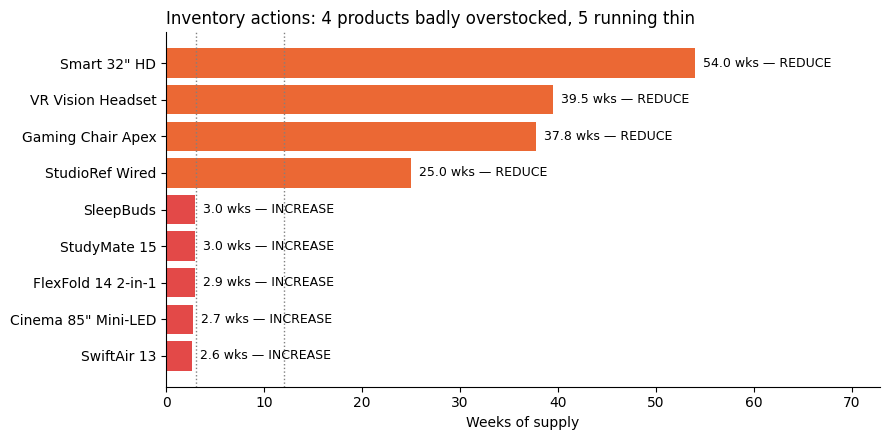

In [37]:
flagged = wos[wos["action"] != "OK"].copy()
flagged["weeks"] = flagged.apply(lambda r: r["weeks_of_cover"] if r["action"] == "INCREASE" else r["weeks_of_supply"], axis=1)
flagged = flagged.sort_values("weeks")

colors = ["#e34948" if a == "INCREASE" else "#eb6834" for a in flagged["action"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(flagged.index, flagged["weeks"], color=colors)

for i, (w, a) in enumerate(zip(flagged["weeks"], flagged["action"])):
    ax.text(w, i, f"  {w:.1f} wks — {a}", va="center", fontsize=9)

ax.axvline(3, color="gray", linestyle=":", linewidth=1)
ax.axvline(12, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Weeks of supply")
ax.set_xlim(0, flagged["weeks"].max() * 1.35)
ax.set_title("Inventory actions: 4 products badly overstocked, 5 running thin", loc="left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../inventory_actions.png", dpi=150)
plt.show()

In [38]:
def pick_color(name, action):
    if action == "REDUCE":
        return "#eb6834"
    if name in ["SwiftAir 13", "FlexFold 14 2-in-1", "StudyMate 15"]:
        return "#b8b7b0"
    return "#e34948"

colors = [pick_color(n, a) for n, a in zip(flagged.index, flagged["action"])]
ax.set_title("4 products badly overstocked; 2 holiday items running thin\n(gray = laptops flagged only because back-to-school inflated recent sales)", loc="left", fontsize=11)

Text(0.0, 1.0, '4 products badly overstocked; 2 holiday items running thin\n(gray = laptops flagged only because back-to-school inflated recent sales)')

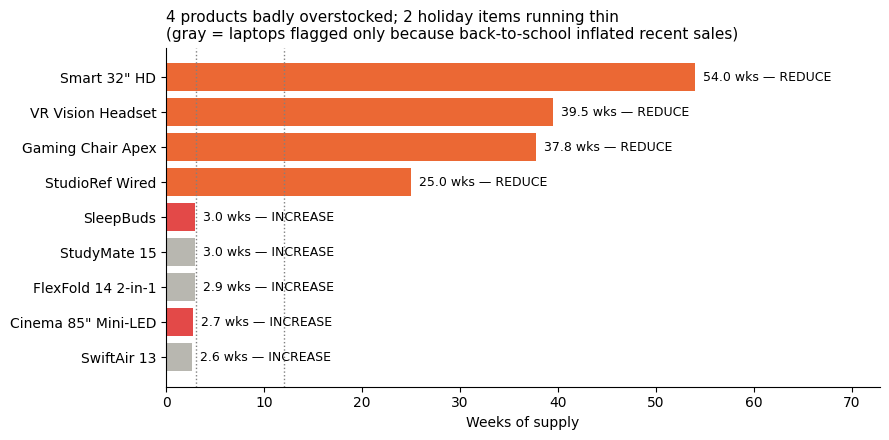

In [39]:
flagged = wos[wos["action"] != "OK"].copy()
flagged["weeks"] = flagged.apply(lambda r: r["weeks_of_cover"] if r["action"] == "INCREASE" else r["weeks_of_supply"], axis=1)
flagged = flagged.sort_values("weeks")

def pick_color(name, action):
    if action == "REDUCE":
        return "#eb6834"
    if name in ["SwiftAir 13", "FlexFold 14 2-in-1", "StudyMate 15"]:
        return "#b8b7b0"
    return "#e34948"

colors = [pick_color(n, a) for n, a in zip(flagged.index, flagged["action"])]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(flagged.index, flagged["weeks"], color=colors)

for i, (w, a) in enumerate(zip(flagged["weeks"], flagged["action"])):
    ax.text(w, i, f"  {w:.1f} wks — {a}", va="center", fontsize=9)

ax.axvline(3, color="gray", linestyle=":", linewidth=1)
ax.axvline(12, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Weeks of supply")
ax.set_xlim(0, flagged["weeks"].max() * 1.35)
ax.set_title("4 products badly overstocked; 2 holiday items running thin\n(gray = laptops flagged only because back-to-school inflated recent sales)", loc="left", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../inventory_actions.png", dpi=150)
plt.show()